In [ ]:
!pip install gymnasium[classic-control]

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
env = gym.make("CartPole-v1", render_mode = "rgb_array")

In [ ]:
alpha = 0.1
gamma = 0.99
eps = 1.0
eps_decay = 0.99
eps_min = 0.01

In [ ]:
n_bins = (5, 10, 5, 10)

obs_space_high = [2.4, 3.0, 0.21, 3.0]
obs_space_low = [-2.4, -3.0, -0.21, -3.0]

bins = [
    np.linspace(obs_space_low[i], obs_space_high[i], n_bins[i] - 1)
    for i in range(len(n_bins))
]
def make_discrete(obs):
  return tuple(np.digitize(obs[i], bins[i]) for i in range(len(obs)))

In [ ]:
q_table = np.zeros(n_bins + (env.action_space.n,))

def choose_a(state):
  if np.random.random() < eps:
      return env.action_space.sample()
  return np.argmax(q_table[state])

In [ ]:
episodes = 3000
rewards = []

for ep in range(episodes):
  obs, _ = env.reset()
  state = make_discrete(obs)

  total_reward = 0
  finished = False

  while not finished:
    action = choose_a(state)
    obs, reward, terminated, truncated, info = env.step(action)

    next_state = make_discrete(obs)
    finished = terminated or truncated

    q_table[state + (action,)] = q_table[state + (action,)] + alpha * (reward + gamma * np.max(q_table[next_state]) - q_table[state + (action,)])
    state = next_state
    total_reward += reward


  rewards.append(total_reward)

  eps = max(eps_min, eps_decay * eps)

  if ep % 100 == 0:
    print(f"Episode {ep}, Average reward: {np.mean(rewards[-100:])}")

Episode 0, Average reward: 24.0
Episode 100, Average reward: 23.39
Episode 200, Average reward: 67.98
Episode 300, Average reward: 103.53
Episode 400, Average reward: 85.44
Episode 500, Average reward: 113.43
Episode 600, Average reward: 100.27
Episode 700, Average reward: 87.52
Episode 800, Average reward: 94.09
Episode 900, Average reward: 104.09
Episode 1000, Average reward: 101.87
Episode 1100, Average reward: 105.0
Episode 1200, Average reward: 109.65
Episode 1300, Average reward: 106.59
Episode 1400, Average reward: 111.87
Episode 1500, Average reward: 110.13
Episode 1600, Average reward: 98.15
Episode 1700, Average reward: 113.43
Episode 1800, Average reward: 108.83
Episode 1900, Average reward: 107.87
Episode 2000, Average reward: 109.21
Episode 2100, Average reward: 110.39
Episode 2200, Average reward: 106.42
Episode 2300, Average reward: 110.05
Episode 2400, Average reward: 105.51
Episode 2500, Average reward: 111.93
Episode 2600, Average reward: 114.29
Episode 2700, Average 

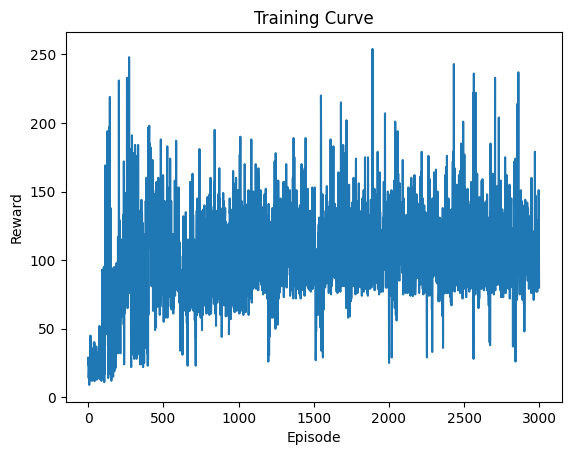

In [ ]:
plt.plot(rewards)
plt.title("Training Curve")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.savefig("training_curves.png")
plt.show()

In [ ]:
obs,_ = env.reset()
state = make_discrete(obs)
finished = False
total_reward = 0

while not finished:
  action = np.argmax(q_table[state])

  obs, reward, terminated, truncated, info = env.step(action)

  state = make_discrete(obs)

  total_reward += reward
  finished = terminated or truncated

print("Trained agent reward: ", total_reward)

env.close()

Trained agent reward:  145.0
